## Optimization code for multilayer or graded porous structure for broadband absorption

#### Input parameters:
- Number of layers
- Layer thickness
- Density of the layer

In [1]:
import numpy as np
from scipy.optimize import minimize

def jca_properties(freq, phi, sigma, alpha_inf, Lambda, Lambda_prime):
    """Calculates Zc and k using the Johnson-Champoux-Allard model."""
    omega = 2 * np.pi * freq
    rho_0 = 1.21  # Air density
    P_0 = 101325  # Atmospheric pressure
    gamma = 1.4
    Pr = 0.71
    mu = 1.84e-5
    
    # Dynamic density (Johnson et al.)
    rho_omega = (alpha_inf * rho_0 / phi) * (1 + (sigma * phi) / (1j * omega * rho_0 * alpha_inf) * np.sqrt(1 + (4 * 1j * alpha_inf**2 * mu * rho_0 * omega) / (sigma**2 * Lambda**2 * phi**2)))
    
    # Dynamic bulk modulus (Champoux-Allard)
    K_omega = (gamma * P_0 / phi) / (gamma - (gamma - 1) / 
               (1 + (8 * mu) / (1j * omega * Pr * rho_0 * Lambda_prime**2) * np.sqrt(1 + (1j * Pr * rho_0 * omega * Lambda_prime**2) / (16 * mu))))
    
    Zc = np.sqrt(rho_omega * K_omega)
    k = omega * np.sqrt(rho_omega / K_omega)
    return Zc, k

def get_layer_matrix(Zc, k, d):
    """Returns the 2x2 Transfer Matrix for a layer of thickness d."""
    T = np.zeros((2, 2), dtype=complex)
    T[0, 0] = np.cos(k * d)
    T[0, 1] = 1j * Zc * np.sin(k * d)
    T[1, 0] = (1j / Zc) * np.sin(k * d)
    T[1, 1] = np.cos(k * d)
    return T

### Three options to define function: 

$\texttt{interpolate\_jca\_from\_granulometry}$

1. The "Discrete Index" Approach (Simplest): \
If only intend to use the four exact granulometries already characterized (Coarse, Medium, Fine, Extra-fine), use a simple lookup table.Advice: Use of a dictionary to store the average values found in Table 7 of the paper. 
 Code Tip: Use np.round or an integer cast to map the optimizer's continuous output to your discrete choices.

```python
def interpolate_jca_from_granulometry(index):
    # Map optimizer's 1.0-4.0 range to specific granulometries
    # 1: Coarse, 2: Medium, 3: Fine, 4: Extra-fine
    data = {
        1: {'phi': 0.41, 'alpha_inf': 1.94, 'sigma': 5377, 'Lambda': 211e-6, 'Lambda_p': 221e-6},
        2: {'phi': 0.45, 'alpha_inf': 1.62, 'sigma': 14811, 'Lambda': 86e-6, 'Lambda_p': 102e-6},
        # ... and so on for Fine/Extra-fine from Table 7
    }
    idx = int(np.clip(np.round(index), 1, 4))
    res = data[idx]
    return res['phi'], res['sigma'], res['alpha_inf'], res['Lambda'], res['Lambda_p']

```

2. The "Morpho-Density" Regression (Recommended for Article 2):\
In your first paper, you found a strong correlation between the characteristic lengths ($\Lambda$, $\Lambda'$) and a variable related to particle dimension, sphericity, and density. Using these regressions makes your second article much more scientifically powerful because it shows you aren't just "guessing" parameters—you are predicting them based on morphology.
Tip: Use Equation 14 from your paper to link density ($\rho$) to porosity ($\phi$).
Tip: Use the Modified Kozeny-Carman formulation (Eq. 18) to calculate airflow resistivity ($\sigma$) based on your equivalent particle diameters ($d_{\text{mean}}$).

3. Key Findings to Include in your Logic:Porosity ($\phi$): \
Your paper shows that porosity increases as granulometry becomes finer. Ensure your interpolation reflects that $\phi$ moves from ~0.41 (Coarse) to ~0.57 (Extra-fine).  Flow Resistivity ($\sigma$): You noted that $\sigma$ increases significantly when granulometry becomes finer, as smaller particles form more compacted structures. In your code, $\sigma$ should scale with $1/d_{mean}^2$ following the Kozeny-Carman logic you validated.  Tortuosity ($\alpha_{\infty}$): Finer granulometries result in higher tortuosity because the acoustic wave follows a longer path. You can use Archie's Law (Eq. 22) with the $\xi$ values you calculated (e.g., 0.41 for Coarse, 2.24 for Extra-fine) to interpolate $\alpha_{\infty}$ dynamically.  

Connection to previous article: "The JCA parameters for the multilayer optimization were determined by interpolating the experimental data retrieved in. Specifically, porosity and tortuosity were linked to the granulometry and density through the linear regressions and Archie’s law coefficients established in the previous characterization." 

In [2]:

import numpy as np
from scipy.optimize import minimize

def interpolate_jca_from_granulometry(index):
    """
    Mapping the optimizer's 'index' to the physical parameters 
    found in your first paper.
    """
    # 1. Reference Data from Paper 1 (Tables 3 & 4)
    # Indices: 1=Coarse, 2=Medium, 3=Fine, 4=Extra-fine
    indices = [1, 2, 3, 4]
    
    # Particle Densities (kg/m^3)
    rho_p_vals = [540.1, 630.2, 691.3, 944.3]
    # Equivalent Particle Diameters (m)
    d_part_vals = [3.54e-3, 2.41e-3, 1.50e-3, 0.50e-3]
    # Archie's Law exponents (xi)
    xi_vals = [0.41, 0.82, 1.06, 2.24]
    # Representative Bulk Densities (kg/m^3) - Typical for your samples
    bulk_rho_vals = [285, 315, 320, 360]

    # 2. Interpolate based on the index provided by the optimizer
    rho_p = np.interp(index, indices, rho_p_vals)
    d_mean = np.interp(index, indices, d_part_vals)
    xi = np.interp(index, indices, xi_vals)
    rho_bulk = np.interp(index, indices, bulk_rho_vals)

    # 3. Calculate JCA Parameters
    phi = 1 - (rho_bulk / rho_p)      # Porosity (Eq. 14)
    alpha_inf = phi**(-xi)            # Tortuosity (Eq. 22)
    
    # Airflow resistivity (Simplified Kozeny-Carman)
    mu = 1.84e-5
    Kc = 5.0 # Kozeny constant calibrated in your paper
    sigma = Kc * (mu / d_mean**2) * ((1 - phi)**2 / phi**3)

    # Characteristic Lengths
    # Using the correlations you observed in the conclusion of Paper 1
    Lambda_prime = d_mean / 2.0
    Lambda = Lambda_prime / 1.5 

    return phi, sigma, alpha_inf, Lambda, Lambda_prime

def objective_function(design_params, freq_range, total_thickness, num_layers):
    """
    Now calls interpolate_jca_from_granulometry with only one argument.
    """
    d_layer = total_thickness / num_layers
    total_absorption = []
    
    for f in freq_range:
        T_total = np.eye(2, dtype=complex)
        
        for i in range(num_layers):
            # No 'density' argument needed here now, it's handled inside!
            params = interpolate_jca_from_granulometry(design_params[i]) 
            
            Zc, k = jca_properties(f, *params)
            T_n = get_layer_matrix(Zc, k, d_layer)
            T_total = np.matmul(T_total, T_n)
        
        # Surface Impedance & Absorption
        Zs = T_total[0, 0] / T_total[1, 0]
        Z0 = 413.5 
        R = (Zs - Z0) / (Zs + Z0)
        alpha = 1 - np.abs(R)**2
        total_absorption.append(alpha)
    
    # We want to minimize (1 - average absorption)
    return 1 - np.mean(total_absorption)


PURE GRANULOMETRY OPTIMIZED DESIGN
Layer Sequence:    ['Coarse', 'Medium', 'Fine', 'Extra-Fine']
Layer Thicknesses: [ 5.  5. 10. 30.] mm
Mean Absorption:   0.698


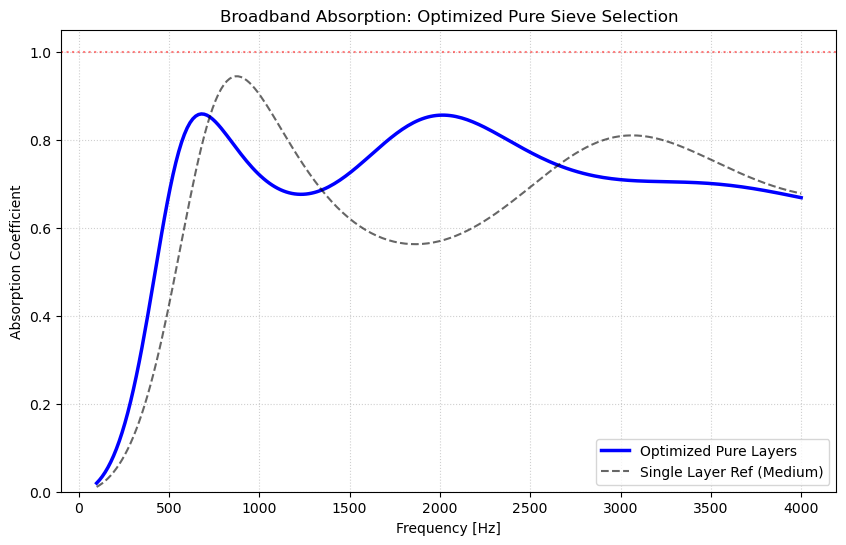

In [3]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
import matplotlib.pyplot as plt

# =================================================================
# 1. ACOUSTIC PHYSICS (JCA MODEL & TMM)
# =================================================================
def jca_properties(f, phi, sigma, alpha_inf, Lambda, Lambda_prime):
    omega = 2 * np.pi * f
    rho_0, P_0, gamma, Pr, eta = 1.213, 101325, 1.4, 0.707, 1.84e-5
    rho_e = (alpha_inf * rho_0 / phi) * (1 + (sigma * phi) / (1j * omega * rho_0 * alpha_inf) * np.sqrt(1 + (4 * 1j * alpha_inf**2 * eta * rho_0 * omega) / (sigma**2 * Lambda**2 * phi**2)))
    K_e = (gamma * P_0 / phi) / (gamma - (gamma - 1) / (1 + (8 * eta) / (1j * omega * Pr * rho_0 * Lambda_prime**2) * np.sqrt(1 + (1j * Pr * rho_0 * omega * Lambda_prime**2) / (16 * eta))))
    return np.sqrt(rho_e * K_e), omega * np.sqrt(rho_e / K_e)

def get_layer_matrix(Zc, k, d):
    T = np.zeros((2, 2), dtype=complex)
    T[0, 0], T[0, 1] = np.cos(k * d), 1j * Zc * np.sin(k * d)
    T[1, 0], T[1, 1] = (1j / Zc) * np.sin(k * d), np.cos(k * d)
    return T

# =================================================================
# 2. MATERIAL CHARACTERIZATION (Pure Granulometry Only)
# =================================================================
def get_pure_jca(index):
    """
    Returns JCA parameters for PURE granulometry only.
    index: 1=Coarse, 2=Medium, 3=Fine, 4=Extra-fine
    """
    # Using the specific values from your Table 7 (validated data)
    data = {
        1: {'phi': 0.41, 'alpha': 1.94, 'sigma': 5377,  'L': 211e-6, 'Lp': 221e-6},
        2: {'phi': 0.45, 'alpha': 1.62, 'sigma': 14811, 'L': 86e-6,  'Lp': 102e-6},
        3: {'phi': 0.54, 'alpha': 1.63, 'sigma': 19934, 'L': 71e-6,  'Lp': 85e-6},
        4: {'phi': 0.57, 'alpha': 2.50, 'sigma': 41344, 'L': 38e-6,  'Lp': 47e-6}
    }
    # Round to nearest integer to force "pure" selection
    idx = int(np.clip(np.round(index), 1, 4))
    res = data[idx]
    return res['phi'], res['sigma'], res['alpha'], res['L'], res['Lp']

# =================================================================
# 3. ABSORPTION CALCULATION
# =================================================================
def calculate_absorption_curve(design_params, freq_range, num_layers):
    indices = design_params[:num_layers]
    thicknesses = design_params[num_layers:]
    
    absorption_curve = []
    for f in freq_range:
        T_total = np.eye(2, dtype=complex)
        for i in range(num_layers):
            # Calls the PURE granulometry function
            params = get_pure_jca(indices[i])
            Zc, k = jca_properties(f, *params)
            T_n = get_layer_matrix(Zc, k, thicknesses[i])
            T_total = np.matmul(T_total, T_n)
        
        Zs = T_total[0, 0] / T_total[1, 0]
        R = (Zs - 413.5) / (Zs + 413.5)
        absorption_curve.append(1 - np.abs(R)**2)
    return np.array(absorption_curve)

def objective_function(design_params, freq_range, num_layers):
    alpha_curve = calculate_absorption_curve(design_params, freq_range, num_layers)
    return 1 - np.mean(alpha_curve)

# =================================================================
# 4. SETTINGS & EXECUTION
# =================================================================
NUM_LAYERS = 4
TOTAL_THICKNESS = 0.05   # in meters 
FREQS = np.linspace(100, 4000, 250)

# Constraints for thickness sum
A = np.zeros(NUM_LAYERS * 2); A[NUM_LAYERS:] = 1  
constraint = LinearConstraint(A, TOTAL_THICKNESS, TOTAL_THICKNESS)
bounds = [(1.0, 4.0)] * NUM_LAYERS + [(0.005, 0.030)] * NUM_LAYERS

# Optimization
# We start with a reasonable guess for layers
initial_guess = [1, 2, 3, 4] + [TOTAL_THICKNESS/NUM_LAYERS]*NUM_LAYERS

res = minimize(objective_function, initial_guess, args=(FREQS, NUM_LAYERS), 
               method='trust-constr', bounds=bounds, constraints=constraint)

# =================================================================
# 5. RESULTS & PLOTTING
# =================================================================
# Round the indices for the final result plot
final_params = res.x.copy()
final_params[:NUM_LAYERS] = np.round(final_params[:NUM_LAYERS])

opt_alpha = calculate_absorption_curve(final_params, FREQS, NUM_LAYERS)
ref_alpha = calculate_absorption_curve([2.0, TOTAL_THICKNESS], FREQS, 1) # Single Medium layer

# Mapping names for output
names = {1: "Coarse", 2: "Medium", 3: "Fine", 4: "Extra-Fine"}
opt_names = [names[int(i)] for i in final_params[:NUM_LAYERS]]

print("\n" + "="*45)
print("PURE GRANULOMETRY OPTIMIZED DESIGN")
print("="*45)
print(f"Layer Sequence:    {opt_names}")
print(f"Layer Thicknesses: {np.round(final_params[NUM_LAYERS:] * 1000, 1)} mm")
print(f"Mean Absorption:   {np.mean(opt_alpha):.3f}")
print("="*45)

plt.figure(figsize=(10, 6))
plt.plot(FREQS, opt_alpha, color='blue', linewidth=2.5, label='Optimized Pure Layers')
plt.plot(FREQS, ref_alpha, color='black', linestyle='--', alpha=0.6, label='Single Layer Ref (Medium)')
plt.axhline(y=1.0, color='red', linestyle=':', alpha=0.5)
plt.title('Broadband Absorption: Optimized Pure Sieve Selection')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Absorption Coefficient')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.ylim(0, 1.05)
plt.show()

Starting Global Search (2 iterations)...
  > Iteration 0: Found better configuration (Mean Alpha: 0.659)
  > Iteration 1: Found better configuration (Mean Alpha: 0.698)

FINAL OPTIMIZED PURE-SIEVE DESIGN
Layer Order (Front->Back): ['Medium', 'Fine', 'Medium', 'Fine']
Layer Thicknesses (mm):    [ 5.  14.4  9.8 20.8]
Mean Alpha (Optimized):    0.702
Mean Alpha (Single Layer): 0.657
Mean Alpha (Fine):         0.711
Mean Alpha (Extra-Fine):   0.616
Mean Alpha (Coarse):       0.574


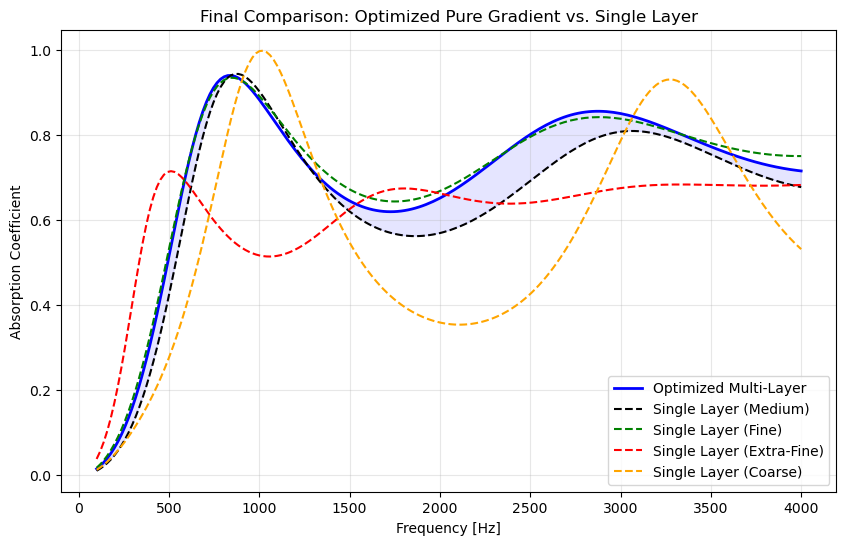

In [6]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
import matplotlib.pyplot as plt
import random

# =================================================================
# 1. CORE PHYSICS (JCA MODEL & TMM)
# =================================================================
def jca_properties(f, phi, sigma, alpha_inf, Lambda, Lambda_prime):
    omega = 2 * np.pi * f
    rho_0, P_0, gamma, Pr, eta = 1.213, 101325, 1.4, 0.707, 1.84e-5
    rho_e = (alpha_inf * rho_0 / phi) * (1 + (sigma * phi) / (1j * omega * rho_0 * alpha_inf) * np.sqrt(1 + (4 * 1j * alpha_inf**2 * eta * rho_0 * omega) / (sigma**2 * Lambda**2 * phi**2)))
    K_e = (gamma * P_0 / phi) / (gamma - (gamma - 1) / (1 + (8 * eta) / (1j * omega * Pr * rho_0 * Lambda_prime**2) * np.sqrt(1 + (1j * Pr * rho_0 * omega * Lambda_prime**2) / (16 * eta))))
    return np.sqrt(rho_e * K_e), omega * np.sqrt(rho_e / K_e)

def get_layer_matrix(Zc, k, d):
    T = np.zeros((2, 2), dtype=complex)
    T[0, 0], T[0, 1] = np.cos(k * d), 1j * Zc * np.sin(k * d)
    T[1, 0], T[1, 1] = (1j / Zc) * np.sin(k * d), np.cos(k * d)
    return T

# =================================================================
# 2. PURE GRANULOMETRY DATA (From Paper 1 Table 7)
# =================================================================
def get_pure_jca(index):
    # We round the index to the nearest integer to ensure we only use pure sieves
    idx = int(np.clip(np.round(index), 1, 4))
    data = {
        1: {'phi': 0.41, 'sigma': 5377,  'alpha': 1.94, 'L': 211e-6, 'Lp': 221e-6}, # Coarse
        2: {'phi': 0.45, 'sigma': 14811, 'alpha': 1.62, 'L': 86e-6,  'Lp': 102e-6}, # Medium
        3: {'phi': 0.54, 'sigma': 19934, 'alpha': 1.63, 'L': 71e-6,  'Lp': 85e-6},  # Fine
        4: {'phi': 0.57, 'sigma': 41344, 'alpha': 2.50, 'L': 38e-6,  'Lp': 47e-6}   # Extra-Fine
    }
    res = data[idx]
    return res['phi'], res['sigma'], res['alpha'], res['L'], res['Lp']

# =================================================================
# 3. ABSORPTION CALCULATION
# =================================================================
def calculate_absorption_curve(design_params, freq_range, num_layers):
    indices = design_params[:num_layers]
    thicknesses = design_params[num_layers:]
    
    absorption_curve = []
    for f in freq_range:
        T_total = np.eye(2, dtype=complex)
        for i in range(num_layers):
            params = get_pure_jca(indices[i])
            Zc, k = jca_properties(f, *params)
            T_n = get_layer_matrix(Zc, k, thicknesses[i])
            T_total = np.matmul(T_total, T_n)
        
        Zs = T_total[0, 0] / T_total[1, 0]
        R = (Zs - 413.5) / (Zs + 413.5)
        absorption_curve.append(1 - np.abs(R)**2)
    return np.array(absorption_curve)

def objective_function(design_params, freq_range, num_layers):
    alpha_curve = calculate_absorption_curve(design_params, freq_range, num_layers)
    return 1 - np.mean(alpha_curve)

# =================================================================
# 4. OPTIMIZATION WITH GLOBAL ITERATIONS
# =================================================================
NUM_LAYERS = 4
TOTAL_THICKNESS = 0.05 
FREQS = np.linspace(100, 4000, 200)

A = np.zeros(NUM_LAYERS * 2); A[NUM_LAYERS:] = 1  
constraint = LinearConstraint(A, TOTAL_THICKNESS, TOTAL_THICKNESS)
bounds = [(1.0, 4.0)] * NUM_LAYERS + [(0.005, 0.030)] * NUM_LAYERS

best_cost = 1.0
best_params = None
num_random_searches = 2 # Iterating 20 times to find the best order/thickness

print(f"Starting Global Search ({num_random_searches} iterations)...")

for i in range(num_random_searches):
    # Random Granulometry Order (Pure integers 1-4)
    rand_indices = [float(random.randint(1, 4)) for _ in range(NUM_LAYERS)]
    # Random Thicknesses summing to TOTAL_THICKNESS
    rand_thicks = np.random.dirichlet(np.ones(NUM_LAYERS), size=1)[0] * TOTAL_THICKNESS
    
    current_guess = list(rand_indices) + list(rand_thicks)
    
    # Local optimization for this random start
    temp_res = minimize(objective_function, current_guess, args=(FREQS, NUM_LAYERS), 
                        method='trust-constr', bounds=bounds, constraints=constraint,
                        options={'maxiter': 40, 'verbose': 0})
    
    if temp_res.fun < best_cost:
        best_cost = temp_res.fun
        best_params = temp_res.x
        print(f"  > Iteration {i}: Found better configuration (Mean Alpha: {1-best_cost:.3f})")

# Final Polish of the best result
res = minimize(objective_function, best_params, args=(FREQS, NUM_LAYERS), 
               method='trust-constr', bounds=bounds, constraints=constraint)

# =================================================================
# 5. RESULTS & COMPARISON
# =================================================================
final_params = res.x.copy()
final_params[:NUM_LAYERS] = np.round(final_params[:NUM_LAYERS]) # Force final result to integers

opt_alpha = calculate_absorption_curve(final_params, FREQS, NUM_LAYERS)
# Single layer Medium (Index 2) reference
ref_alpha = calculate_absorption_curve([2.0] + [TOTAL_THICKNESS], FREQS, 1)
ref_alpha2 = calculate_absorption_curve([3.0] + [TOTAL_THICKNESS], FREQS, 1) # Single layer Fine reference
ref_alpha3 = calculate_absorption_curve([4.0] + [TOTAL_THICKNESS], FREQS, 1) # Single layer Extra-Fine reference
ref_alpha4 = calculate_absorption_curve([1.0] + [TOTAL_THICKNESS], FREQS, 1) # Single layer Coarse reference

names = {1: "Coarse", 2: "Medium", 3: "Fine", 4: "Extra-Fine"}
opt_names = [names[int(i)] for i in final_params[:NUM_LAYERS]]

print("\n" + "="*45)
print("FINAL OPTIMIZED PURE-SIEVE DESIGN")
print("="*45)
print(f"Layer Order (Front->Back): {opt_names}")
print(f"Layer Thicknesses (mm):    {np.round(final_params[NUM_LAYERS:] * 1000, 1)}")
print(f"Mean Alpha (Optimized):    {np.mean(opt_alpha):.3f}")
print(f"Mean Alpha (Single Layer): {np.mean(ref_alpha):.3f}")
print(f"Mean Alpha (Fine):         {np.mean(ref_alpha2):.3f}")
print(f"Mean Alpha (Extra-Fine):   {np.mean(ref_alpha3):.3f}")
print(f"Mean Alpha (Coarse):       {np.mean(ref_alpha4):.3f}")
print("="*45)

plt.figure(figsize=(10, 6))
plt.plot(FREQS, opt_alpha, color='blue', linewidth=2, label='Optimized Multi-Layer')
plt.plot(FREQS, ref_alpha, color='black', linestyle='--', label='Single Layer (Medium)')
plt.plot(FREQS, ref_alpha2, color='green', linestyle='--', label='Single Layer (Fine)')
plt.plot(FREQS, ref_alpha3, color='red', linestyle='--', label='Single Layer (Extra-Fine)')
plt.plot(FREQS, ref_alpha4, color='orange', linestyle='--', label='Single Layer (Coarse)')
plt.fill_between(FREQS, opt_alpha, ref_alpha, where=(opt_alpha > ref_alpha), color='blue', alpha=0.1)
plt.title('Final Comparison: Optimized Pure Gradient vs. Single Layer')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Absorption Coefficient')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()